# Codeathon 1
### Alanna Hazlett
### uwa6xv
### February 23rd, 2025

### Examine and understand data

In [1]:
# All imports
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import PIL #Python Image Library 

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from keras import regularizers
import random 

seed_value = 123
tf.random.set_seed(seed_value)
np.random.seed(seed_value)
random.seed(seed_value)

2025-02-22 11:24:16.633079: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-22 11:24:16.891756: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-22 11:24:16.975664: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-22 11:24:17.567609: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#import pathlib

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos.tar', origin=dataset_url, extract=True)
data_dir = pathlib.Path(data_dir).with_suffix('')

In [3]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print("There are", image_count, "images.")

There are 3670 images.


There are 633 daisies.


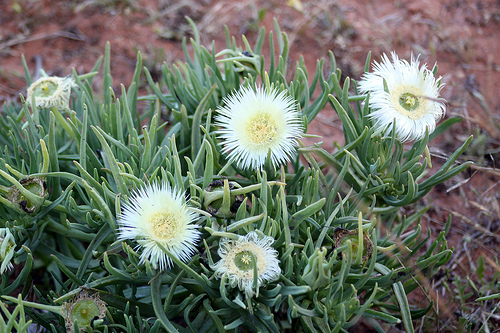

In [4]:
daisies = list(data_dir.glob('daisy/*'))
print("There are", len(daisies), "daisies.")
PIL.Image.open(str(daisies[10]))

There are 898 dandelions.


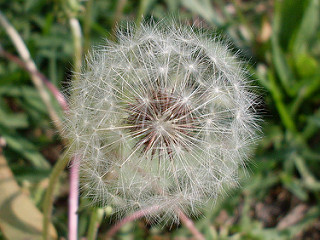

In [5]:
dandelions = list(data_dir.glob('dandelion/*'))
print("There are", len(dandelions), "dandelions.")
PIL.Image.open(str(dandelions[10]))

There are 641 roses.


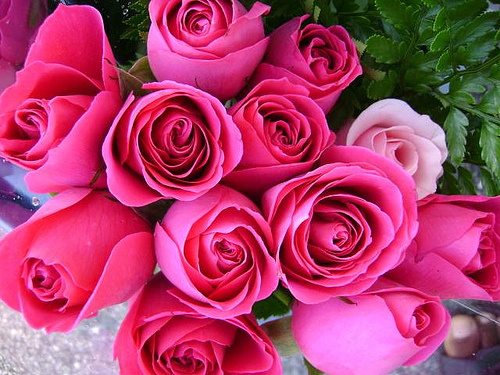

In [6]:
roses = list(data_dir.glob('roses/*'))
print("There are", len(roses), "roses.")
PIL.Image.open(str(roses[10]))

There are 699 sunflowers.


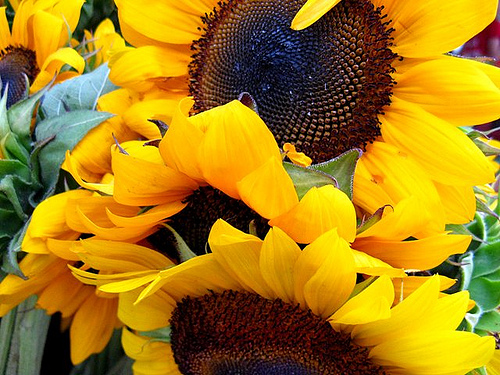

In [7]:
sunflowers = list(data_dir.glob('sunflowers/*'))
print("There are", len(sunflowers), "sunflowers.")
PIL.Image.open(str(sunflowers[10]))

There are 799 tulips.


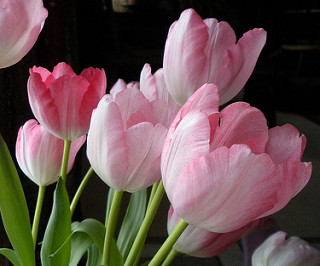

In [8]:
tulips = list(data_dir.glob('tulips/*'))
print("There are", len(tulips), "tulips.")
PIL.Image.open(str(tulips[10]))

### Build an input pipeline

In [9]:
batch_size = 32
img_height = 180
img_width = 180

#### Training Data

In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


2025-02-22 11:24:31.033153: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 45008 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:01:00.0, compute capability: 8.6
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recogn

In [11]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


2025-02-22 11:24:34.822655: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


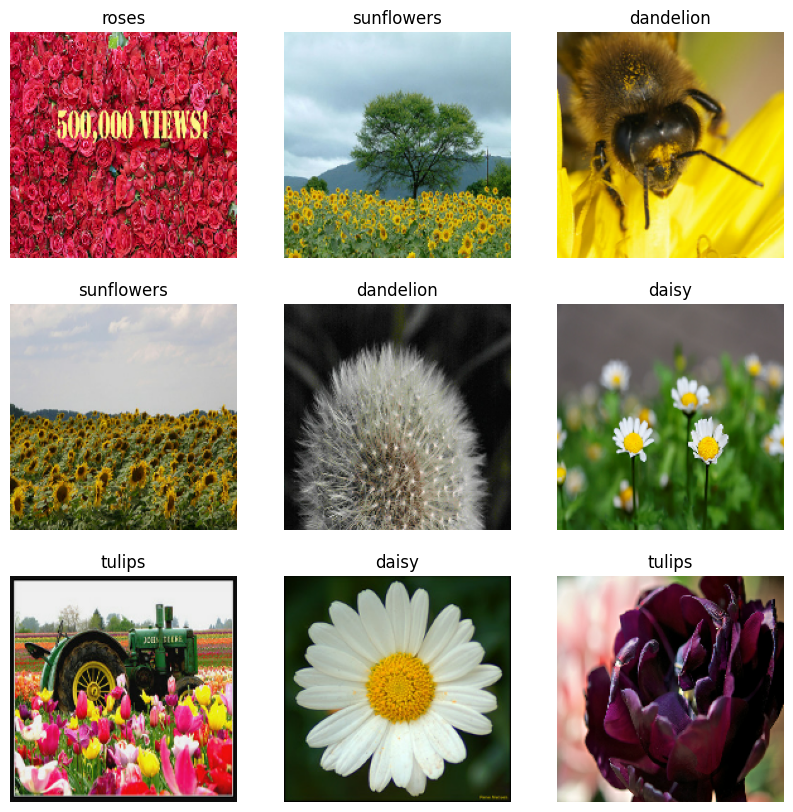

In [12]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

#### Validation Data

In [13]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [14]:
print(val_ds.class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


2025-02-22 11:24:36.837457: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


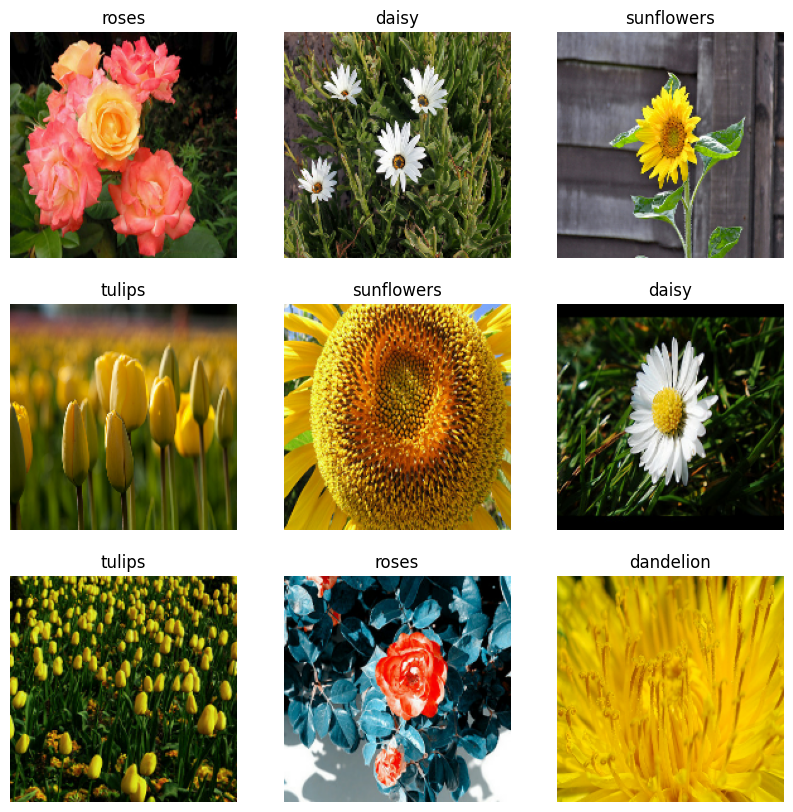

In [15]:
plt.figure(figsize=(10, 10))
for images, labels in val_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [16]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


### Prepare the data

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [18]:
normalization_layer = layers.Rescaling(1./255)

In [19]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


## Model 1 - The Basic Model from the tutorial

### Build the model

In [20]:
model1 = keras.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

### Compile and train the model

In [21]:
model1.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [22]:
model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 180, 180, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 90, 90, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 90, 90, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 45, 45, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 45, 45, 64)        1

In [23]:
epochs1=10
history1 = model1.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs1
)

Epoch 1/10


2025-02-22 11:24:47.658186: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90501
W0000 00:00:1740241488.277019  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241488.351683  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241488.353618  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241488.382222  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241488.382865  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241488.383249  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241488.384055  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241488.384860  859124 gpu_

 1/92 [..............................] - ETA: 6:32 - loss: 1.5953 - accuracy: 0.2500

W0000 00:00:1740241490.367820  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241490.368384  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241490.368877  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241490.369848  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241490.370566  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241490.371412  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241490.372418  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241490.373327  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241490.374226  859124 gp

 3/92 [..............................] - ETA: 9s - loss: 2.7283 - accuracy: 0.1979 

...

54/92 [================>.............] - ETA: 0s - loss: 0.8601 - accuracy: 0.6634

W0000 00:00:1740241495.465391  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241495.465643  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241495.466046  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241495.466273  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241495.466586  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241495.466804  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241495.467324  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241495.467839  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241495.468339  859124 gp

92/92 [==============================] - 1s 10ms/step - loss: 0.8493 - accuracy: 0.6710 - val_loss: 0.9031 - val_accuracy: 0.6621
Epoch 4/10
88/92 [===========================>..] - ETA: 0s - loss: 0.6477 - accuracy: 0.7564

W0000 00:00:1740241496.933959  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241496.934209  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241496.934504  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241496.934729  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241496.935041  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241496.935257  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241496.935777  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241496.936292  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241496.936789  859124 gp

92/92 [==============================] - 1s 11ms/step - loss: 0.6550 - accuracy: 0.7531 - val_loss: 0.9461 - val_accuracy: 0.6308
Epoch 5/10
92/92 [==============================] - 1s 10ms/step - loss: 0.4446 - accuracy: 0.8382 - val_loss: 0.9609 - val_accuracy: 0.6717
Epoch 6/10
92/92 [==============================] - 1s 11ms/step - loss: 0.2708 - accuracy: 0.9149 - val_loss: 1.1281 - val_accuracy: 0.6621
Epoch 7/10
92/92 [==============================] - 1s 10ms/step - loss: 0.1575 - accuracy: 0.9533 - val_loss: 1.2660 - val_accuracy: 0.6444
Epoch 8/10
92/92 [==============================] - 1s 10ms/step - loss: 0.0793 - accuracy: 0.9789 - val_loss: 1.5187 - val_accuracy: 0.6608
Epoch 9/10
92/92 [==============================] - 1s 11ms/step - loss: 0.0423 - accuracy: 0.9905 - val_loss: 1.6284 - val_accuracy: 0.6376
Epoch 10/10
92/92 [==============================] - 1s 11ms/step - loss: 0.0313 - accuracy: 0.9935 - val_loss: 1.7147 - val_accuracy: 0.6499


### Visualize training results

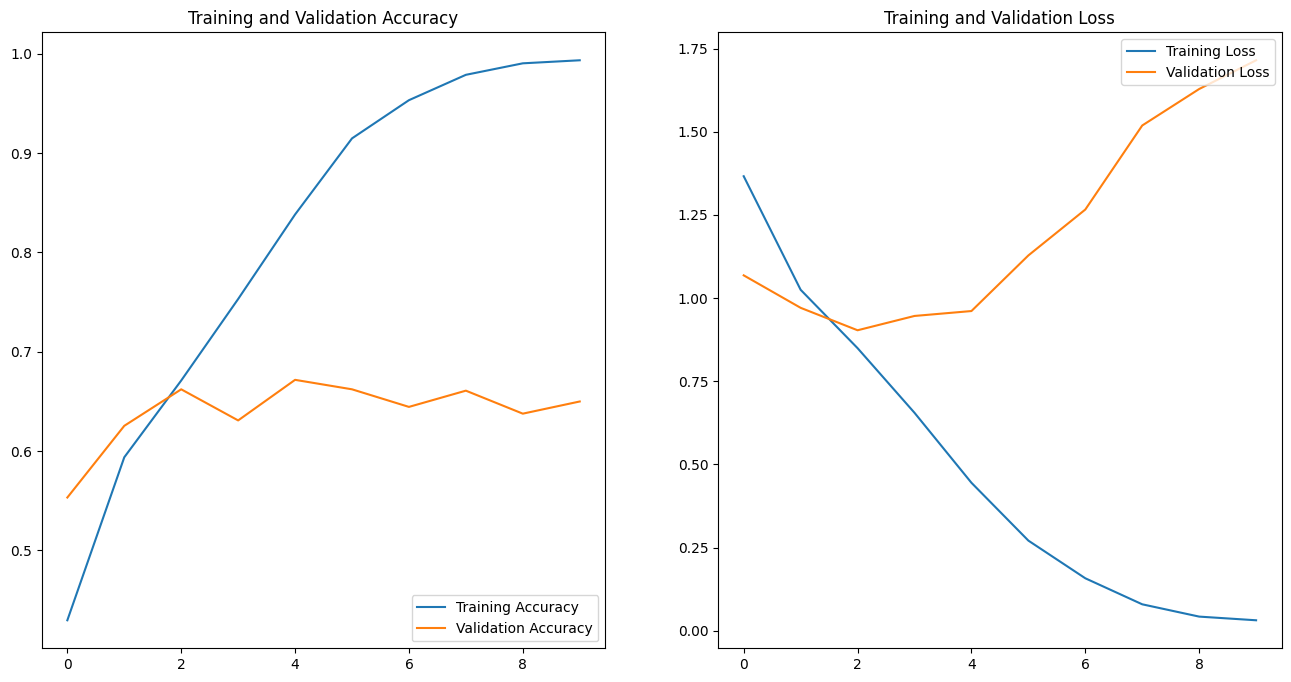

In [24]:
acc1 = history1.history['accuracy']
val_acc1 = history1.history['val_accuracy']

loss1 = history1.history['loss']
val_loss1 = history1.history['val_loss']

epochs_range1 = range(epochs1)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range1, acc1, label='Training Accuracy')
plt.plot(epochs_range1, val_acc1, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range1, loss1, label='Training Loss')
plt.plot(epochs_range1, val_loss1, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

    We see that the model is overfitted, it has learned the training dataset so well that it does not generalize well to the validation dataset. This is notable by the significant decrease in the validation accuracy compared to the training accuracy and the high loss for the validation dataset compared to the loss of the training dataset. We will want to add some optimization to reduce the overfitting.
    
    We see below the model has falsely classified our new data.

### Predict on new data

In [25]:
sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

img = tf.keras.utils.load_img(
    sunflower_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions1 = model1.predict(img_array)
score1 = tf.nn.softmax(predictions1[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score1)], 100 * np.max(score1))
)

1/1 [==============================] - 0s 292ms/step
This image most likely belongs to tulips with a 67.53 percent confidence.


W0000 00:00:1740241503.983483  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241503.983610  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241503.983676  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241503.983761  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241503.983872  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241503.983965  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241503.984040  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241503.984115  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241503.984217  859124 gp

## Model 2 - Data Augmentation and Dropout from tutorial

### Build the model

In [26]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

In [27]:
model2 = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, name="outputs")
])

### Compile and train the model

In [28]:
model2.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
print(model2.summary())
epochs2=15
history2 = model2.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs2
)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 180, 180, 3)       0         
                                                                 
 rescaling_2 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 180, 180, 16)      448       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 90, 90, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 90, 90, 32)        4640      
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 45, 45, 32)        0         
 g2D)                                                 

2025-02-22 11:25:06.294184: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1026] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_2/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is

 1/92 [..............................] - ETA: 6:23 - loss: 1.6385 - accuracy: 0.2812

W0000 00:00:1740241508.703291  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241508.704138  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241508.705092  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241508.705959  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241508.706815  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241508.708280  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241508.709740  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241508.710623  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241508.711708  859124 gp

 3/92 [..............................] - ETA: 22s - loss: 2.5221 - accuracy: 0.2386

W0000 00:00:1740241509.165700  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241509.165910  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241509.166074  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241509.166246  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241509.166414  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241509.166603  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241509.166787  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241509.167014  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241509.167220  859124 gp

92/92 [==============================] - 6s 20ms/step - loss: 1.4902 - accuracy: 0.3263 - val_loss: 1.1404 - val_accuracy: 0.5409
Epoch 2/15
92/92 [==============================] - ETA: 0s - loss: 1.1391 - accuracy: 0.5167

W0000 00:00:1740241511.620429  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241511.620644  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241511.620810  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241511.620981  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241511.621153  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241511.621344  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241511.621526  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241511.621755  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241511.621957  859124 gp

92/92 [==============================] - 1s 14ms/step - loss: 1.1391 - accuracy: 0.5167 - val_loss: 1.0873 - val_accuracy: 0.5286
Epoch 3/15
92/92 [==============================] - 1s 13ms/step - loss: 1.0242 - accuracy: 0.5926 - val_loss: 0.9420 - val_accuracy: 0.6131
Epoch 4/15
92/92 [==============================] - 1s 13ms/step - loss: 0.9600 - accuracy: 0.6304 - val_loss: 0.9809 - val_accuracy: 0.6090
Epoch 5/15
92/92 [==============================] - 1s 12ms/step - loss: 0.8799 - accuracy: 0.6478 - val_loss: 0.9781 - val_accuracy: 0.6117
Epoch 6/15
92/92 [==============================] - 1s 12ms/step - loss: 0.8316 - accuracy: 0.6805 - val_loss: 0.8731 - val_accuracy: 0.6689
Epoch 7/15
92/92 [==============================] - 1s 13ms/step - loss: 0.8050 - accuracy: 0.6918 - val_loss: 0.8973 - val_accuracy: 0.6594
Epoch 8/15
92/92 [==============================] - 1s 13ms/step - loss: 0.7404 - accuracy: 0.7095 - val_loss: 0.8202 - val_accuracy: 0.6553
Epoch 9/15
92/92 [======

### Visualize training results

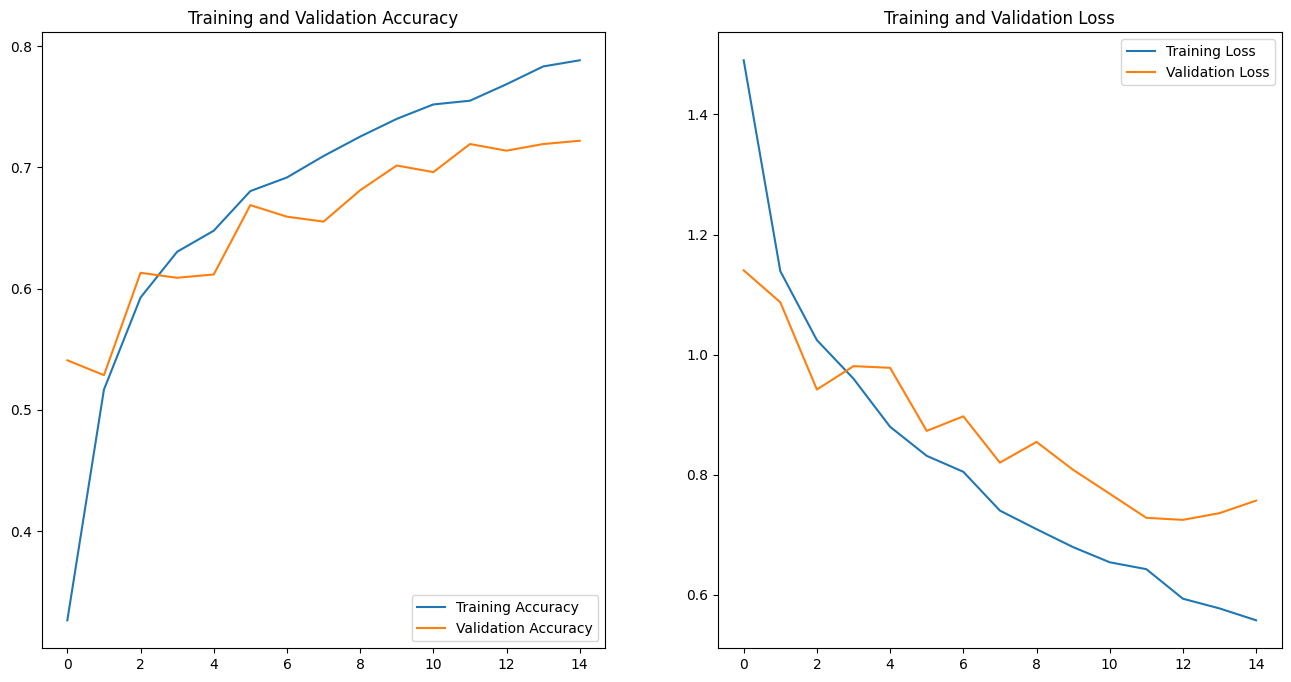

In [29]:
acc2 = history2.history['accuracy']
val_acc2 = history2.history['val_accuracy']

loss2 = history2.history['loss']
val_loss2 = history2.history['val_loss']

epochs_range2 = range(epochs2)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range2, acc2, label='Training Accuracy')
plt.plot(epochs_range2, val_acc2, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range2, loss2, label='Training Loss')
plt.plot(epochs_range2, val_loss2, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

    We see that this model has less overfitting compared to the first model, so the data augmentation and dropout appears to have helped. We do achieve less accuracy for the training dataset, however. Are we able to create a model that can achieve high accuracy for both training and validation without overfitting? 
    
    We see below the model has falsely classified the new data.

### Predict on new data

In [30]:
# Already created from first model
# sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
# sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

# img = tf.keras.utils.load_img(
#     sunflower_path, target_size=(img_height, img_width)
# )
# img_array = tf.keras.utils.img_to_array(img)
# img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions2 = model2.predict(img_array)
score2 = tf.nn.softmax(predictions2[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score2)], 100 * np.max(score2))
)

1/1 [==============================] - 0s 122ms/step
This image most likely belongs to tulips with a 49.99 percent confidence.


W0000 00:00:1740241527.679061  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241527.679196  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241527.679269  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241527.679353  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241527.679486  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241527.679584  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241527.679658  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241527.679738  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241527.679837  859124 gp

## Model 3 - Adding layers and L1 Regularization 

### Build the model

In [31]:
model3 = keras.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu', kernel_regularizer=keras.regularizers.L1(l1=0.01)),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),# kernel_regularizer=keras.regularizers.L1(l1=0.001)),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),# kernel_regularizer=keras.regularizers.L1(l1=0.001)),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),# kernel_regularizer=keras.regularizers.L1(l1=0.01)),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),# kernel_regularizer=keras.regularizers.L1(l1=0.01)),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

### Compile and train the model

In [32]:
model3.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
print(model3.summary())
epochs3=10
history3 = model3.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs3
)

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_3 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_6 (Conv2D)           (None, 180, 180, 16)      448       
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 90, 90, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 90, 90, 32)        4640      
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 45, 45, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 45, 45, 64)       

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1740241529.656687  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241529.657068  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241529.657221  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241529.657352  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241529.657502  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241529.657623  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241529.657778  859124 gpu_timer.cc:114] Skipping

 6/92 [>.............................] - ETA: 1s - loss: 2.0193 - accuracy: 0.2448

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1740241530.580109  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241530.580289  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241530.580436  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241530.580567  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241530.580716  859124 gpu_timer.cc:114] Skipping the delay kernel, measu

31/92 [=========>....................] - ETA: 0s - loss: 1.9135 - accuracy: 0.3161

...

88/92 [===========================>..] - ETA: 0s - loss: 0.8345 - accuracy: 0.7340

W0000 00:00:1740241538.235379  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241538.235524  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241538.235615  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241538.235691  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241538.235764  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241538.235842  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241538.235941  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241538.236019  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241538.236100  859124 gp

92/92 [==============================] - 1s 11ms/step - loss: 0.8357 - accuracy: 0.7333 - val_loss: 0.9788 - val_accuracy: 0.6785
Epoch 8/10
89/92 [============================>.] - ETA: 0s - loss: 0.7568 - accuracy: 0.7588

W0000 00:00:1740241539.267811  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241539.267947  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241539.268037  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241539.268112  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241539.268195  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241539.268276  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241539.268371  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241539.268449  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241539.268530  859124 gp

92/92 [==============================] - 1s 12ms/step - loss: 0.7557 - accuracy: 0.7589 - val_loss: 1.0358 - val_accuracy: 0.6335
Epoch 9/10
92/92 [==============================] - 1s 12ms/step - loss: 0.7102 - accuracy: 0.7742 - val_loss: 0.9271 - val_accuracy: 0.6826
Epoch 10/10
92/92 [==============================] - 1s 11ms/step - loss: 0.6213 - accuracy: 0.8171 - val_loss: 0.9580 - val_accuracy: 0.7139


### Visualize training results

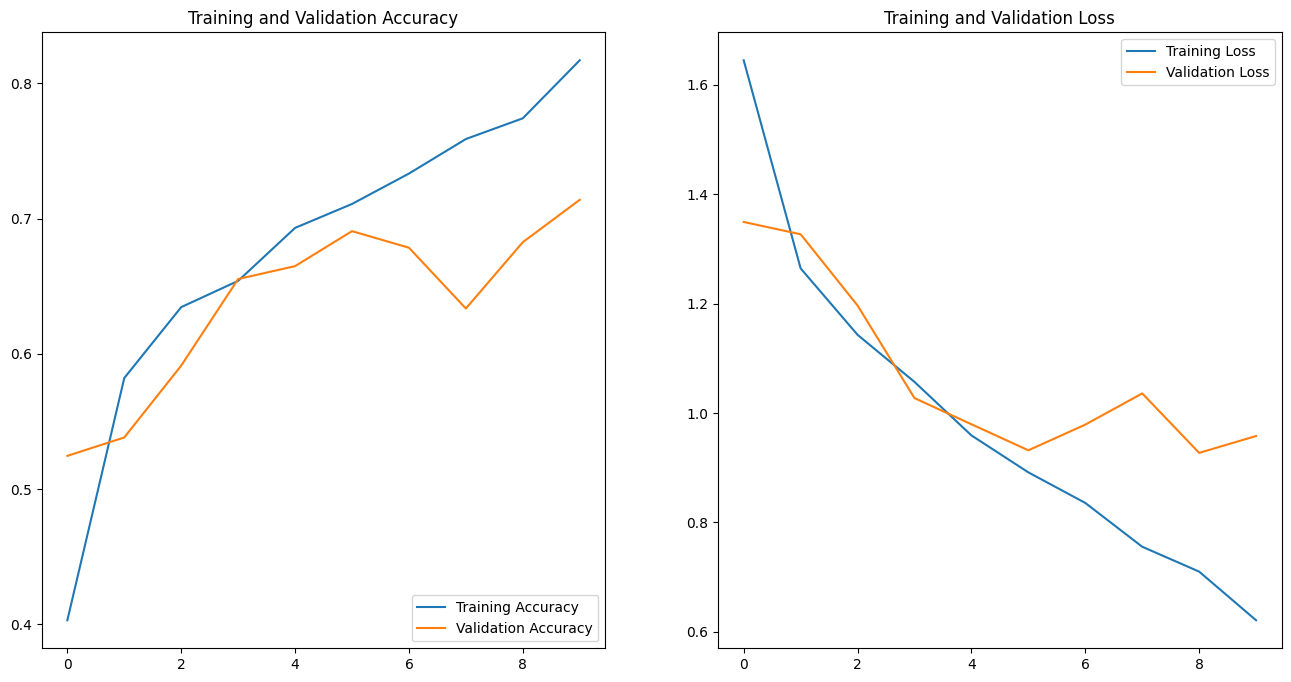

In [33]:
acc3 = history3.history['accuracy']
val_acc3 = history3.history['val_accuracy']

loss3 = history3.history['loss']
val_loss3 = history3.history['val_loss']

epochs_range3 = range(epochs3)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range3, acc3, label='Training Accuracy')
plt.plot(epochs_range3, val_acc3, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range3, loss3, label='Training Loss')
plt.plot(epochs_range3, val_loss3, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

    I attempted to add in a different form of optimization of L1 regularization in hopes of preventing overfitting. I added layers to the network in hopes of improving the accuracy of the training set and subsequently the validation set, however this did not go as I hoped. We have quite a bit of overfitting here. Increasing the value of lambda for L1 reduces the accuracy for the training set and made a slight improvement in the accuracy of the validation set, but not enough. Adjusting the layers and lambda value felt a lot like a give and take of either having good accuracy values or a reduction in overfitting, but never did it seem that both were possible. 
    
    We see the model has successfully classified the new data and with a high confidence. 

### Predict on new data

In [34]:
# Already created in first model
# sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
# sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

# img = tf.keras.utils.load_img(
#     sunflower_path, target_size=(img_height, img_width)
# )
# img_array = tf.keras.utils.img_to_array(img)
# img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions3 = model3.predict(img_array)
score3 = tf.nn.softmax(predictions3[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score3)], 100 * np.max(score3))
)

1/1 [==============================] - 0s 147ms/step
This image most likely belongs to sunflowers with a 99.02 percent confidence.


W0000 00:00:1740241542.203633  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241542.203759  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241542.203930  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241542.204043  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241542.204140  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241542.204229  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241542.204291  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241542.204350  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241542.204440  859124 gp

## Model 4 - Best without transfer learning. Added a layer, increased drop out, increased epochs.

### Build the model

In [35]:
model4 = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),  
  layers.Dropout(0.7, seed=123),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, name="outputs")
])   

### Compile and train the model

In [36]:
model4.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
print(model4.summary())
epochs4=40
history4 = model4.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs4
)

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 180, 180, 3)       0         
                                                                 
 rescaling_4 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_11 (Conv2D)          (None, 180, 180, 16)      448       
                                                                 
 max_pooling2d_11 (MaxPooli  (None, 90, 90, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_12 (Conv2D)          (None, 90, 90, 32)        4640      
                                                                 
 max_pooling2d_12 (MaxPooli  (None, 45, 45, 32)        0         
 ng2D)                                                

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1740241544.900466  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740

 2/92 [..............................] - ETA: 6s - loss: 1.6058 - accuracy: 0.2812  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1740241545.380760  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241545.380908  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241545.381004  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be 

14/92 [===>..........................] - ETA: 1s - loss: 1.5899 - accuracy: 0.2768

...

85/92 [==========================>...] - ETA: 0s - loss: 1.3027 - accuracy: 0.4303

W0000 00:00:1740241546.255964  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241546.256098  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241546.256211  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241546.256341  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241546.256428  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241546.256531  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241546.256615  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241546.256700  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241546.256797  859124 gp

92/92 [==============================] - 4s 17ms/step - loss: 1.2941 - accuracy: 0.4384 - val_loss: 1.1104 - val_accuracy: 0.5695
Epoch 2/40
90/92 [============================>.] - ETA: 0s - loss: 1.0482 - accuracy: 0.5794

W0000 00:00:1740241547.699547  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241547.699684  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241547.699797  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241547.699925  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241547.700012  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241547.700116  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241547.700209  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241547.700296  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241547.700395  859124 gp

92/92 [==============================] - 1s 13ms/step - loss: 1.0470 - accuracy: 0.5790 - val_loss: 0.9819 - val_accuracy: 0.6117
Epoch 3/40
92/92 [==============================] - 1s 14ms/step - loss: 0.9574 - accuracy: 0.6165 - val_loss: 0.9103 - val_accuracy: 0.6335
Epoch 4/40
92/92 [==============================] - 1s 12ms/step - loss: 0.8896 - accuracy: 0.6557 - val_loss: 0.8330 - val_accuracy: 0.6757
Epoch 5/40
92/92 [==============================] - 1s 14ms/step - loss: 0.8471 - accuracy: 0.6662 - val_loss: 0.7879 - val_accuracy: 0.6757
Epoch 6/40
92/92 [==============================] - 1s 12ms/step - loss: 0.8038 - accuracy: 0.6771 - val_loss: 0.8776 - val_accuracy: 0.6703
Epoch 7/40
92/92 [==============================] - 1s 13ms/step - loss: 0.8001 - accuracy: 0.6945 - val_loss: 0.7596 - val_accuracy: 0.6962
Epoch 8/40
92/92 [==============================] - 1s 14ms/step - loss: 0.7494 - accuracy: 0.7101 - val_loss: 0.7114 - val_accuracy: 0.7098
Epoch 9/40
92/92 [======

### Visualize training results

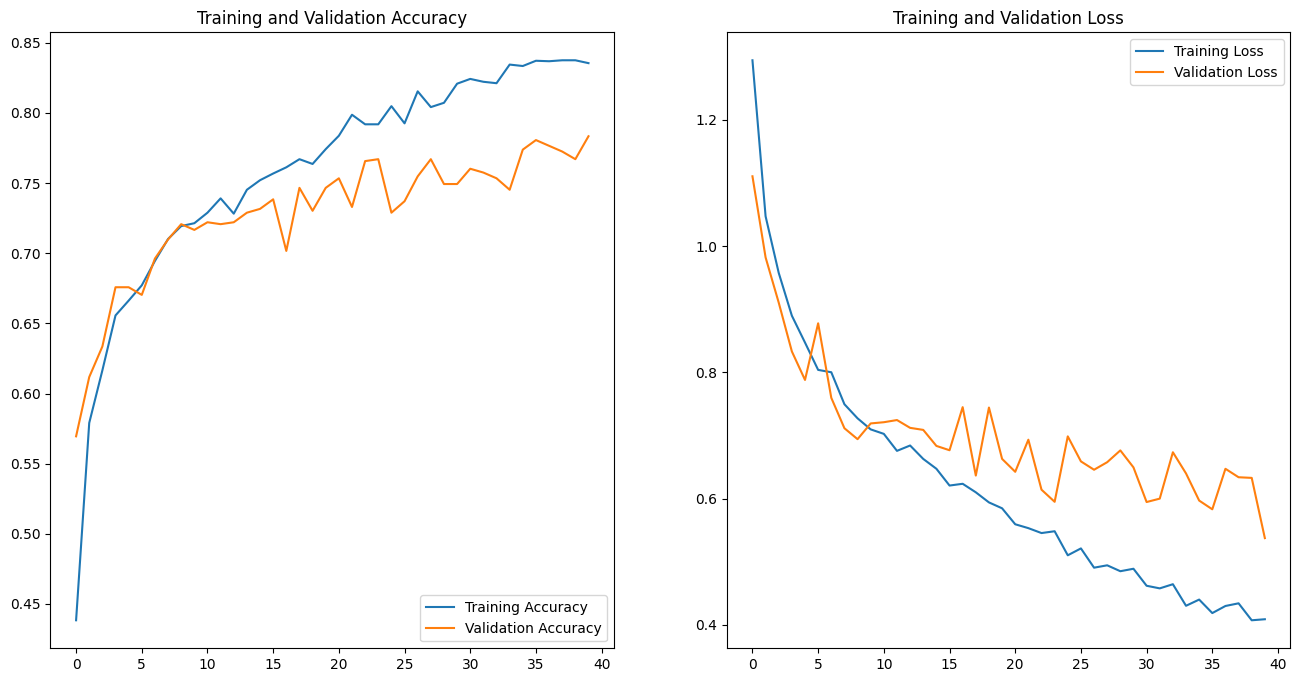

In [37]:
acc4 = history4.history['accuracy']
val_acc4 = history4.history['val_accuracy']

loss4 = history4.history['loss']
val_loss4 = history4.history['val_loss']

epochs_range4 = range(epochs4)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range4, acc4, label='Training Accuracy')
plt.plot(epochs_range4, val_acc4, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range4, loss4, label='Training Loss')
plt.plot(epochs_range4, val_loss4, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

     The addition of a layer, increasing dropout to 0.7, and increasing epochs does seem to have help keep accuracy somewhat high, although not high enough for our standards, and reduce overfitting. This model is very inefficient with such a high dropout rate it takes quite a bit of time to train at 40 epochs. I adjusted the number of epochs to 80 to see where the loss leveled off at and performance stopped increasing and 40 epochs was that mark. This was the best I could make of our initial tutorial model without utilizing transfer learning. I am curious if it is possible to consistently acheive over 0.8 validation accuracy on this dataset with our tutorial model and optimization wihtout transfer learning. 
     
     We see below that the model has successfully classified the new data with a high confidence. 

### Predict on new data

In [38]:
# Already created in first model
# sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
# sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

# img = tf.keras.utils.load_img(
#     sunflower_path, target_size=(img_height, img_width)
# )
# img_array = tf.keras.utils.img_to_array(img)
# img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions4 = model4.predict(img_array)
score4 = tf.nn.softmax(predictions4[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score4)], 100 * np.max(score4))
)

1/1 [==============================] - 0s 123ms/step
This image most likely belongs to sunflowers with a 98.42 percent confidence.


## Model 5 - Utilizing transfer learning. Finally acheiving our validation accuracy of over 0.8! 

### Build the model

In [39]:
resnet_model = keras.Sequential()
model5 = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=(img_height, img_width, 3),
    pooling="max",
    classes=num_classes#,
    #classifier_activation="softmax"
)
# Don't change what ResNet50 has already learned
for layer in model5.layers:
    layer.trainable = False

resnet_model.add(model5)
resnet_model.add(keras.layers.Dropout(0.3, seed=123))
resnet_model.add(keras.layers.Flatten())
resnet_model.add(keras.layers.Dense(64, activation='relu'))
resnet_model.add(keras.layers.Dense(num_classes, activation='softmax'))

### Compile and train the model

In [40]:
resnet_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),#from_logits=True),
              metrics=['accuracy'])

In [41]:
resnet_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dropout_2 (Dropout)         (None, 2048)              0         
                                                                 
 flatten_4 (Flatten)         (None, 2048)              0         
                                                                 
 dense_6 (Dense)             (None, 64)                131136    
                                                                 
 dense_7 (Dense)             (None, 5)                 325       
                                                                 
Total params: 23719173 (90.48 MB)
Trainable params: 131461 (513.52 KB)
Non-trainable params: 23587712 (89.98 MB)
_________________________________________________________________


    Something to note: Here we see that this model has a lot of non-trainable parameters, meanwhile all of our models thus far have had no non-trainable parameters. This difference is because of the transfer learning. All of these non-trainable parameters are the ones coming in from ResNet50. 

In [42]:
epochs5 = 15
history5 = resnet_model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs5
)

Epoch 1/15


W0000 00:00:1740241603.133408  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241603.134298  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241603.134680  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241603.135147  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241603.136134  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241603.162562  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241603.163107  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241603.163814  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241603.164929  859124 gp

 1/92 [..............................] - ETA: 9:31 - loss: 11.0389 - accuracy: 0.2500

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1740241603.868171  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241603.868532  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241603.868842  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241603.869244  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241603.870143  859124 gpu_timer.cc:114] Skipping the delay kernel, measu

 4/92 [>.............................] - ETA: 9s - loss: 8.6247 - accuracy: 0.2266 

...

92/92 [==============================] - ETA: 0s - loss: 1.5534 - accuracy: 0.6233

W0000 00:00:1740241608.339739  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.340089  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.340381  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.340761  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.341602  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.342042  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.342482  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.343073  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.343998  859124 gp

92/92 [==============================] - 11s 52ms/step - loss: 1.5534 - accuracy: 0.6233 - val_loss: 0.6344 - val_accuracy: 0.7752
Epoch 2/15
11/92 [==>...........................] - ETA: 1s - loss: 0.6268 - accuracy: 0.7762

W0000 00:00:1740241608.654974  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.655282  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.655534  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.655848  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.656540  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.656899  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.657255  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.657738  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241608.658490  859124 gp

92/92 [==============================] - 2s 27ms/step - loss: 0.6391 - accuracy: 0.7776 - val_loss: 0.5213 - val_accuracy: 0.8188
Epoch 3/15
92/92 [==============================] - 3s 27ms/step - loss: 0.5092 - accuracy: 0.8134 - val_loss: 0.4373 - val_accuracy: 0.8311
Epoch 4/15
92/92 [==============================] - 2s 27ms/step - loss: 0.4658 - accuracy: 0.8229 - val_loss: 0.4330 - val_accuracy: 0.8420
Epoch 5/15
92/92 [==============================] - 3s 28ms/step - loss: 0.3962 - accuracy: 0.8583 - val_loss: 0.3681 - val_accuracy: 0.8597
Epoch 6/15
92/92 [==============================] - 2s 26ms/step - loss: 0.3595 - accuracy: 0.8668 - val_loss: 0.3925 - val_accuracy: 0.8515
Epoch 7/15
92/92 [==============================] - 3s 28ms/step - loss: 0.3343 - accuracy: 0.8869 - val_loss: 0.3748 - val_accuracy: 0.8529
Epoch 8/15
92/92 [==============================] - 2s 26ms/step - loss: 0.3074 - accuracy: 0.8845 - val_loss: 0.4088 - val_accuracy: 0.8678
Epoch 9/15
92/92 [======

### Visualize training results

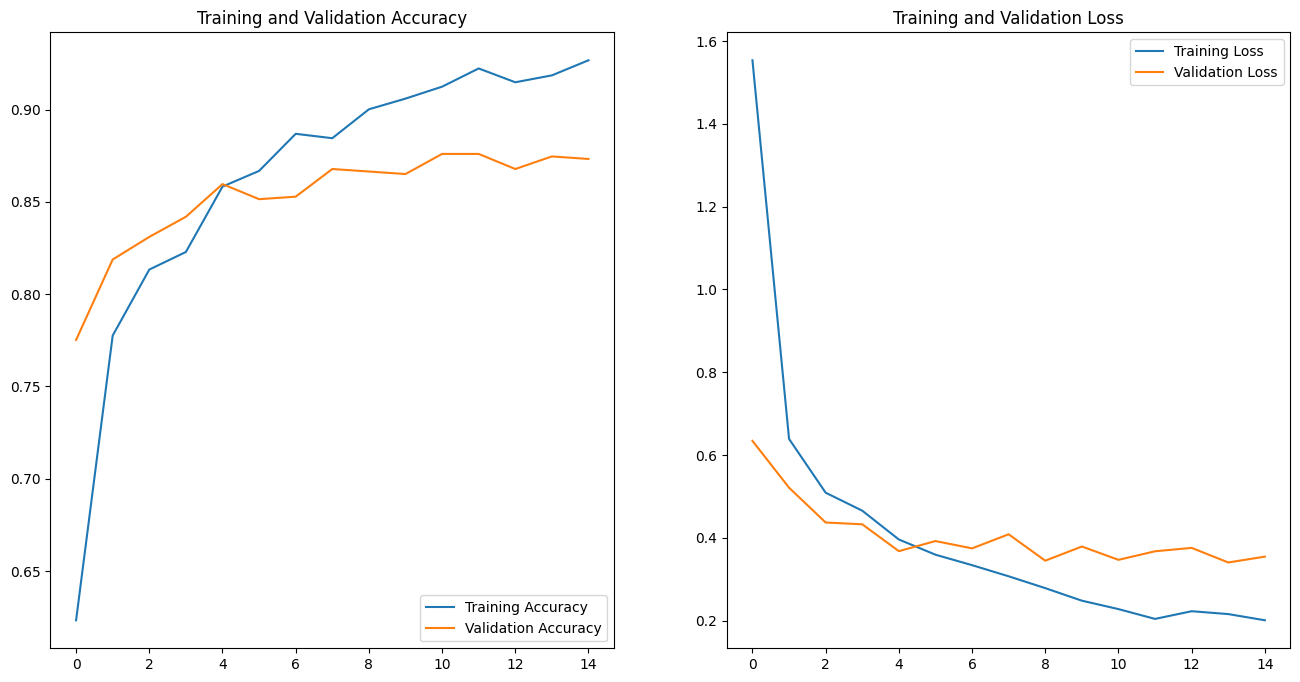

In [43]:
acc5 = history5.history['accuracy']
val_acc5 = history5.history['val_accuracy']

loss5 = history5.history['loss']
val_loss5 = history5.history['val_loss']

epochs_range5 = range(epochs5)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range5, acc5, label='Training Accuracy')
plt.plot(epochs_range5, val_acc5, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range5, loss5, label='Training Loss')
plt.plot(epochs_range5, val_loss5, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

    Transfer learning, the use of ResNet50, has successfully improved the validation accuracy easily over .8. For this model I did try adjusting a few things: dropout rate and the number of epochs. As you increase the dropout rate you have to increase the epochs. Utilizing no dropout created quite a bit of overfitting with the model nearly perfectly learning the training data, but still acheiving around the 0.86-0.88 validation accuracy, as above. So I decided to utilize a little bit of drop out to reduce the overfitting, in hopes of better generalization. In previous iterations, I also tried the addition of data augmentation, which also helped decrease the overfitting. 
    
    Something interesting to note, is while this model has the best performance of the bunch, it has a low confidence on it's prediction (below). 

### Predict on new data
Use your model to classify an image that wasn't included in the training or validation sets.

In [44]:
# Already created from first model
# sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
# sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

# img = tf.keras.utils.load_img(
#     sunflower_path, target_size=(img_height, img_width)
# )
# img_array = tf.keras.utils.img_to_array(img)
# img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions5 = resnet_model.predict(img_array)
score5 = tf.nn.softmax(predictions5[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score5)], 100 * np.max(score5))
)

1/1 [==============================] - 2s 2s/step
This image most likely belongs to sunflowers with a 40.40 percent confidence.


W0000 00:00:1740241644.911283  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241644.911431  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241644.911511  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241644.911588  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241644.911713  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241644.911776  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241644.911836  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241644.911904  859124 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1740241644.911985  859124 gp